# Usporedba modela: Isolation Forest vs. duboki autoenkoder

Ova bilježnica objedinjuje rezultate obje pojedinačno istrenirane i evaluirane bilježnice (isolation_forest.ipynb i autoencoder.ipynb) radi izravne usporedbe na istom testnom skupu (30 %, kronološki posljednji dio podatkovnog skupa). Ista podjela kao u isolation_forest.ipynb i autoencoder.ipynb. Ne trenira modele iznova, nego učitava već istrenirane, spremljene modele iz obje bilježnice

Datoteke isolation_forest_model.pkl, amount_scaler_if.pkl i time_scaler_if.pkl iz isolation_forest.ipynb, te autoencoder_model.keras i autoencoder_threshold.pkl iz autoencoder_keras_tensor.ipynb potrebno je učitati u runtime ove bilježnice (ćelija u nastavku otvara sučelje za učitavanje datoteka).

In [92]:
!pip install -q kagglehub scikit-learn pandas matplotlib seaborn joblib tensorflow

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)
from tensorflow import keras

RANDOM_STATE = 42

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

## 1. Učitavanje istreniranih modela i pragova

Pragovi su preuzeti izravno iz pojedinačnih bilježnica. Pokretanjem sljedeće ćelije potrebno je učitati svih pet datoteka navedenih u uvodu.

In [93]:
from google.colab import files
uploaded = files.upload()

Saving amount_scaler_if.pkl to amount_scaler_if.pkl
Saving autoencoder_model.keras to autoencoder_model.keras
Saving autoencoder_threshold.pkl to autoencoder_threshold.pkl
Saving isolation_forest_model.pkl to isolation_forest_model.pkl
Saving time_scaler_if.pkl to time_scaler_if.pkl


In [94]:
amount_scaler = joblib.load('amount_scaler_if.pkl')
time_scaler = joblib.load('time_scaler_if.pkl')
print("Both scalers uploaded successfully.")

Both scalers uploaded successfully.


### 2. Priprema podatkovnog skupa

Identična podjela (63 % učenje / 7 % validacija / 30 % testiranje, kronološki) kao u obje pojedinačne bilježnice. Koristi se samo zadnjih 30 % (testni skup).

In [96]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(f"{path}/creditcard.csv")

n = len(df)
train_end = int(n * 0.63)
val_end = int(n * 0.70)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

val_df['Amount_scaled'] = amount_scaler.transform(val_df[['Amount']])
val_df['Time_scaled'] = time_scaler.transform(val_df[['Time']])

feature_cols = [c for c in df.columns if c.startswith('V')] + ['Amount_scaled', 'Time_scaled']

X_val = val_df[feature_cols]
y_val = val_df['Class'].values


print(f"Validation: {X_val.shape}, Fraud rate: {y_val.mean() * 100:.4f} %")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Validation: (19936, 30), Fraud rate: 0.1003 %
Test: (85443, 30), Fraud rate: 0.1264 %


In [97]:
bundle = joblib.load('isolation_forest_model.pkl')

IF_THRESHOLD = bundle['threshold']
AE_THRESHOLD = joblib.load('autoencoder_threshold.pkl')

iso_forest = bundle['model']
autoencoder = keras.models.load_model('autoencoder_model.keras')

print("Both models uploaded successfully.")

Both models uploaded successfully.


## 3. Izračun anomalijskih rezultata

Za Isolation Forest koristi se već ustaljena konvencija (veći rezultat = veća anomalnost), a za autoenkoder pogreška rekonstrukcije (srednja kvadratna pogreška po transakciji).



In [105]:
if_scores = -iso_forest.score_samples(X_val)

ae_reconstructed = autoencoder.predict(X_val, verbose=0)
ae_scores = np.mean(np.square(X_val.values - ae_reconstructed), axis=1)

## 4. Usporedba prema evaluacijskim metrikama

Pragovi ispod odgovaraju finalnim konfiguracijama usvojenima u poglavljima 4.4.3. i 4.5.2. završnog rada.

In [106]:
if_pred = (if_scores >= IF_THRESHOLD).astype(int)
ae_pred = (ae_scores > AE_THRESHOLD).astype(int)

comparison = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC'],
    'Isolation Forest': [
        precision_score(y_val, if_pred),
        recall_score(y_val, if_pred),
        f1_score(y_val, if_pred),
        roc_auc_score(y_val, if_scores),
        average_precision_score(y_val, if_scores)
    ],
    'Autoencoder': [
        precision_score(y_val, ae_pred),
        recall_score(y_val, ae_pred),
        f1_score(y_val, ae_pred),
        roc_auc_score(y_val, ae_scores),
        average_precision_score(y_val, ae_scores)
    ]
})
comparison

,Metric,Isolation Forest,Autoencoder
0,Precision,0.030928,0.047619
1,Recall,0.600000,0.500000
2,F1-score,0.058824,0.086957
3,ROC-AUC,0.946028,0.918249
4,PR-AUC,0.019805,0.033863


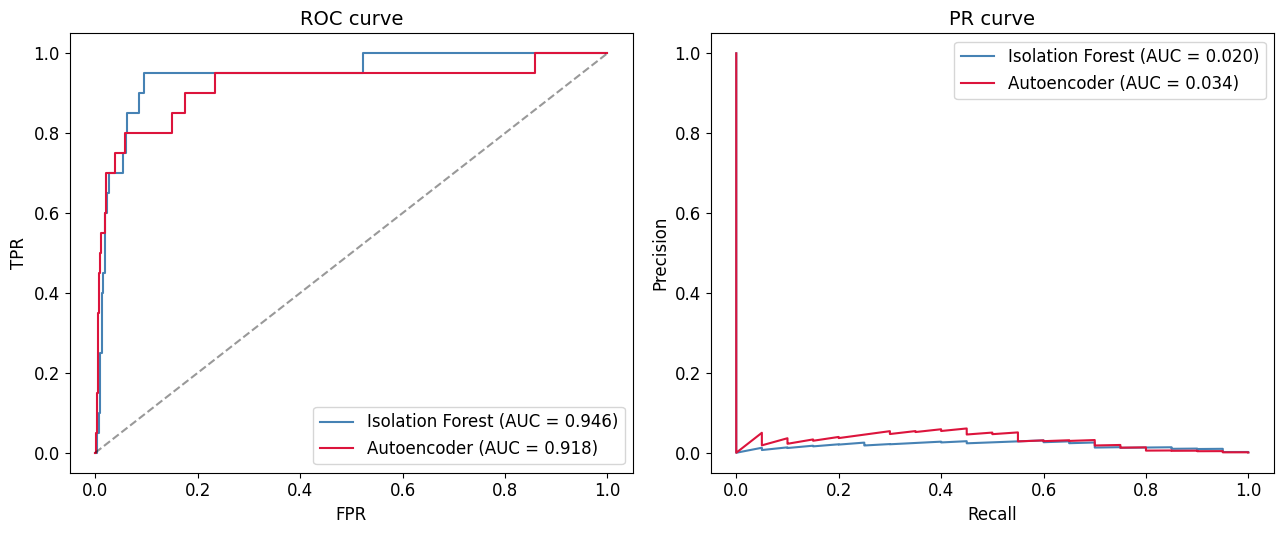

In [107]:
fpr_if, tpr_if, _ = roc_curve(y_val, if_scores)
fpr_ae, tpr_ae, _ = roc_curve(y_val, ae_scores)
prec_if, rec_if, _ = precision_recall_curve(y_val, if_scores)
prec_ae, rec_ae, _ = precision_recall_curve(y_val, ae_scores)

roc_auc_if = roc_auc_score(y_val, if_scores)
roc_auc_ae = roc_auc_score(y_val, ae_scores)
pr_auc_if = average_precision_score(y_val, if_scores)
pr_auc_ae = average_precision_score(y_val, ae_scores)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC = {roc_auc_if:.3f})', color='steelblue')
axes[0].plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC = {roc_auc_ae:.3f})', color='crimson')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC curve')
axes[0].legend()

axes[1].plot(rec_if, prec_if, label=f'Isolation Forest (AUC = {pr_auc_if:.3f})', color='steelblue')
axes[1].plot(rec_ae, prec_ae, label=f'Autoencoder (AUC = {pr_auc_ae:.3f})', color='crimson')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR curve')
axes[1].legend()

plt.tight_layout()
plt.show()

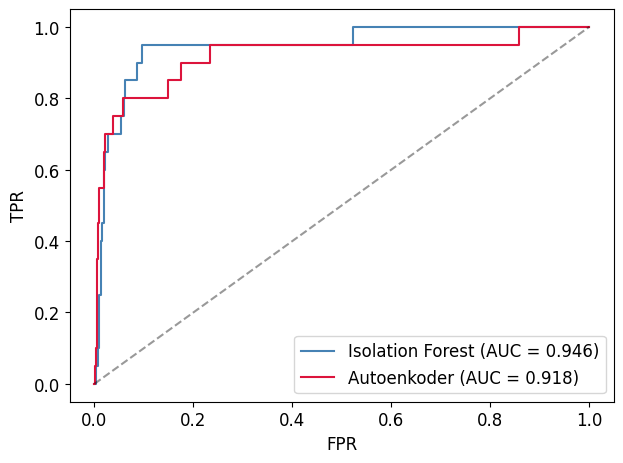

In [108]:
plt.plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC = {roc_auc_if:.3f})', color='steelblue')
plt.plot(fpr_ae, tpr_ae, label=f'Autoenkoder (AUC = {roc_auc_ae:.3f})', color='crimson')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.tight_layout()
plt.savefig('roc-curves.png', dpi=300, bbox_inches='tight')
plt.show()

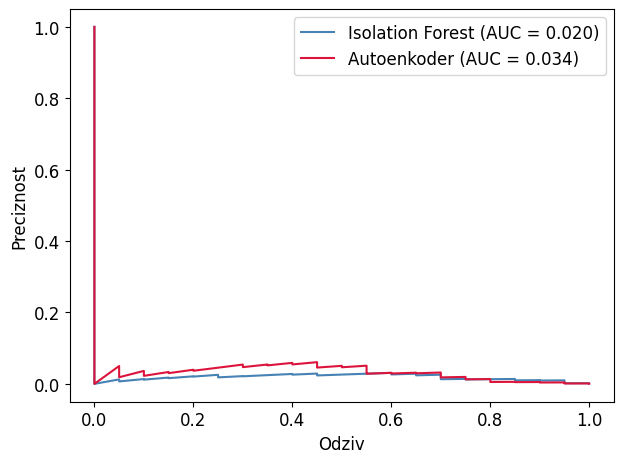

In [109]:
plt.plot(rec_if, prec_if, label=f'Isolation Forest (AUC = {pr_auc_if:.3f})', color='steelblue')
plt.plot(rec_ae, prec_ae, label=f'Autoenkoder (AUC = {pr_auc_ae:.3f})', color='crimson')
plt.xlabel('Odziv')
plt.ylabel('Preciznost')
plt.legend()
plt.tight_layout()
plt.savefig('pr-curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Usporedba vremena obrade

Mjerenje se provodi na hardveru dodijeljenom u trenutnoj Colab sesiji (dijeljeni CPU).

Svaki model se mjeri 5 puta, obradom cijelog testnog skupa odjednom (skupna, ne pojedinačna obrada), a prosjek se dijeli brojem transakcija radi procjene prosječnog vremena po transakcijski.

Napomena: apsolutne vrijednosti ovise o hardveru na kojem se bilježnica izvršava (u Colab okruženju to je dijeljeni CPU), pa je usporedba između dva modela na istom stroju informativnija od same apsolutne brojke.

In [110]:
import platform
print("Processor/Environment:", platform.processor() or "N/A (Colab assigns a generic name by default)")

N_RUNS = 5

if_times = []
for _ in range(N_RUNS):
    start = time.perf_counter()
    _ = iso_forest.score_samples(X_val)
    if_times.append(time.perf_counter() - start)

ae_times = []
for _ in range(N_RUNS):
    start = time.perf_counter()
    _ = autoencoder.predict(X_val, verbose=0)
    ae_times.append(time.perf_counter() - start)

if_avg_total = np.mean(if_times)
ae_avg_total = np.mean(ae_times)
if_per_tx_ms = (if_avg_total / len(X_val)) * 1000
ae_per_tx_ms = (ae_avg_total / len(X_val)) * 1000

timing_comparison = pd.DataFrame({
    'Model': ['Isolation Forest', 'Autoencoder'],
    'Average total time (s)': [if_avg_total, ae_avg_total],
    'Average time per transaction (ms)': [if_per_tx_ms, ae_per_tx_ms]
})
timing_comparison

Processor/Environment: x86_64


,Model,Average total time (s),Average time per transaction (ms)
0,Isolation Forest,0.351781,0.017646
1,Autoencoder,1.078541,0.054100


## 6. Preklapanje detekcija i provjera potencijala združivanja

In [111]:
fraud_idx = np.where(y_val == 1)[0]

if_hits = set(fraud_idx[if_pred[fraud_idx] == 1])
ae_hits = set(fraud_idx[ae_pred[fraud_idx] == 1])

both = if_hits & ae_hits
only_if = if_hits - ae_hits
only_ae = ae_hits - if_hits
missed_by_both = set(fraud_idx) - (if_hits | ae_hits)

print(f"Total number of frauds in validation: {len(fraud_idx)}")
print(f"Recognised by both models: {len(both)}")
print(f"Recognised just by Isolation Foresta: {len(only_if)}")
print(f"Recognised just by autoencodera: {len(only_ae)}")
print(f"Missed by both models: {len(missed_by_both)}")

Total number of frauds in validation: 20
Recognised by both models: 10
Recognised just by Isolation Foresta: 2
Recognised just by autoencodera: 0
Missed by both models: 8


In [112]:
ensemble_pred = ((if_pred == 1) | (ae_pred == 1)).astype(int)

ensemble_comparison = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-score'],
    'Isolation Forest': [
        precision_score(y_val, if_pred),
        recall_score(y_val, if_pred),
        f1_score(y_val, if_pred)
    ],
    'Autoencoder': [
        precision_score(y_val, ae_pred),
        recall_score(y_val, ae_pred),
        f1_score(y_val, ae_pred)
    ],
    'Ensemble (OR)': [
        precision_score(y_val, ensemble_pred),
        recall_score(y_val, ensemble_pred),
        f1_score(y_val, ensemble_pred)
    ]
})
ensemble_comparison

,Metric,Isolation Forest,Autoencoder,Ensemble (OR)
0,Precision,0.030928,0.047619,0.026667
1,Recall,0.600000,0.500000,0.600000
2,F1-score,0.058824,0.086957,0.051064
